# The Kernel Trick: From Linear to Nonlinear

**Objective:** Understand why linear classifiers fail on nonlinear data and how the kernel trick enables SVMs to learn complex decision boundaries without explicitly computing high-dimensional feature maps.

**Key Concepts:**
- The failure of linear classifiers on non-linearly separable data
- The kernel trick: $k(x, y) = \langle \Phi(x), \Phi(y) \rangle$
- Polynomial and RBF (Gaussian) kernels
- Implicit feature mapping into high-dimensional spaces

**Package:** `rkhs_kernel_methods`

In [4]:
import sys, os
# Ensure src/ is on the path regardless of where Jupyter was launched
for _candidate in (os.path.join(os.getcwd(), 'src'),
                   os.path.join(os.getcwd(), '..', 'src')):
    _p = os.path.abspath(_candidate)
    if os.path.isdir(_p) and _p not in sys.path:
        sys.path.insert(0, _p)
        break


In [5]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

from rkhs_kernel_methods import (
    make_linearly_separable,
    make_nonlinear_datasets,
    load_all_datasets,
    train_linear_svm,
    train_kernel_svm,
    plot_decision_boundary,
    plot_dataset,
    plot_kernel_comparison,
    evaluate_model,
    compare_kernels,
    linear_kernel,
    polynomial_kernel,
    rbf_kernel,
    kernel_matrix,
    compute_kernel_gram,
    set_style,
    set_random_seed,
)

set_style()
set_random_seed(42)
print("Package loaded.")

Package loaded.


## 1. The Problem: When Linear Fails

We generate two classic nonlinear datasets: **circles** (concentric rings) and **moons** (interleaving crescents). There is **no straight line** that can separate these classes.

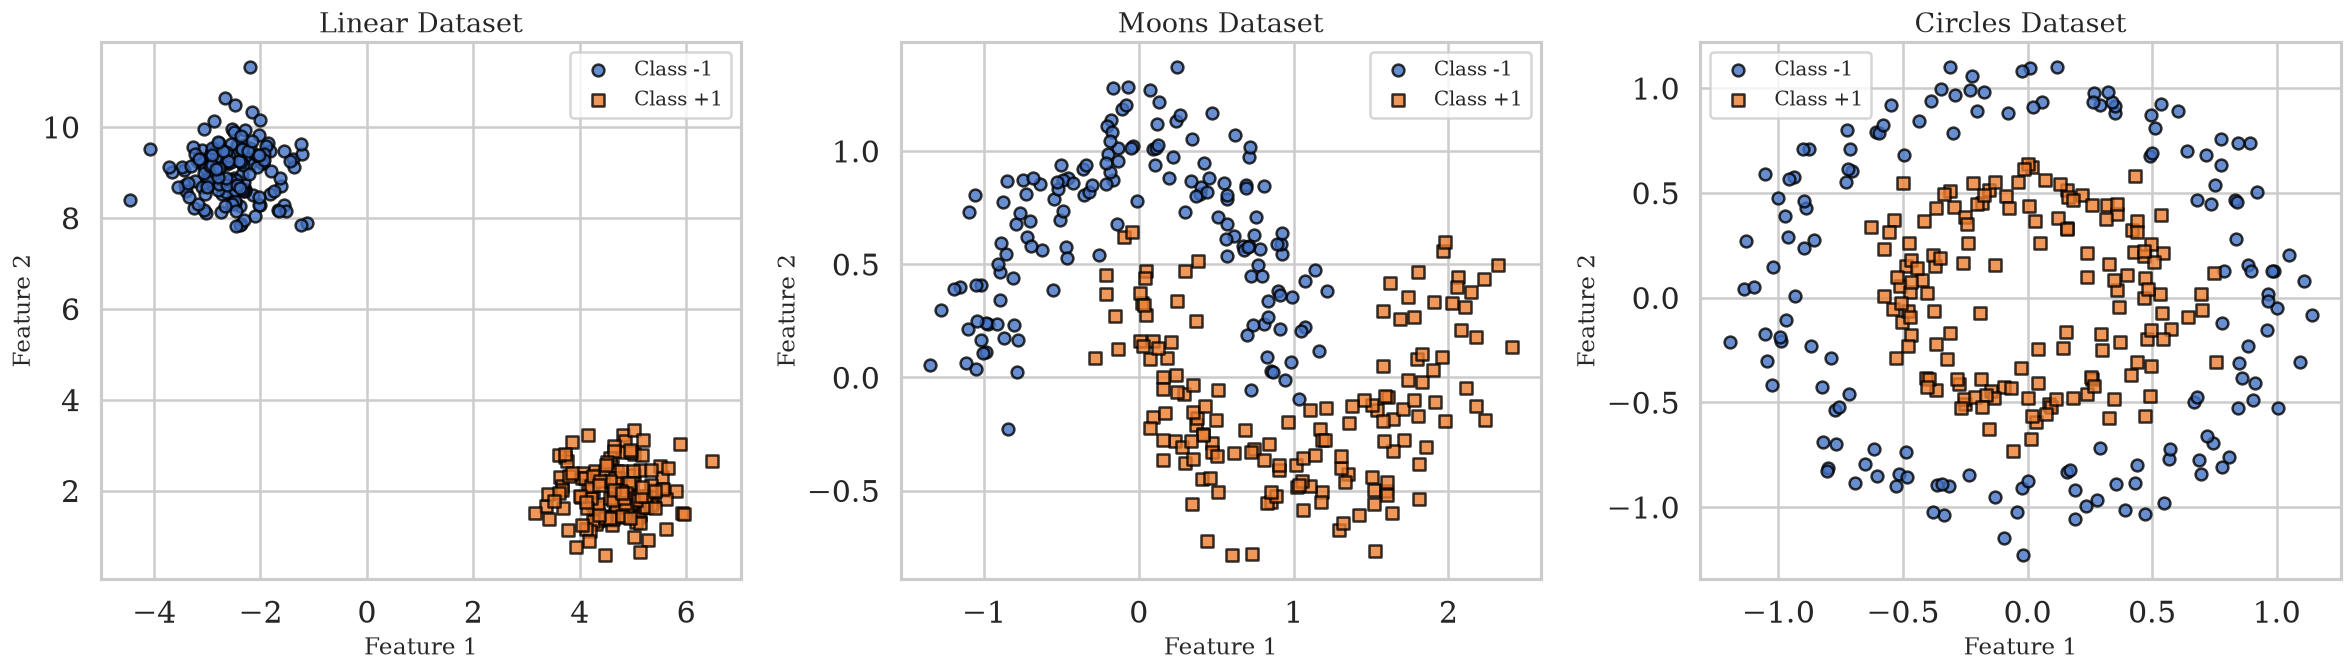

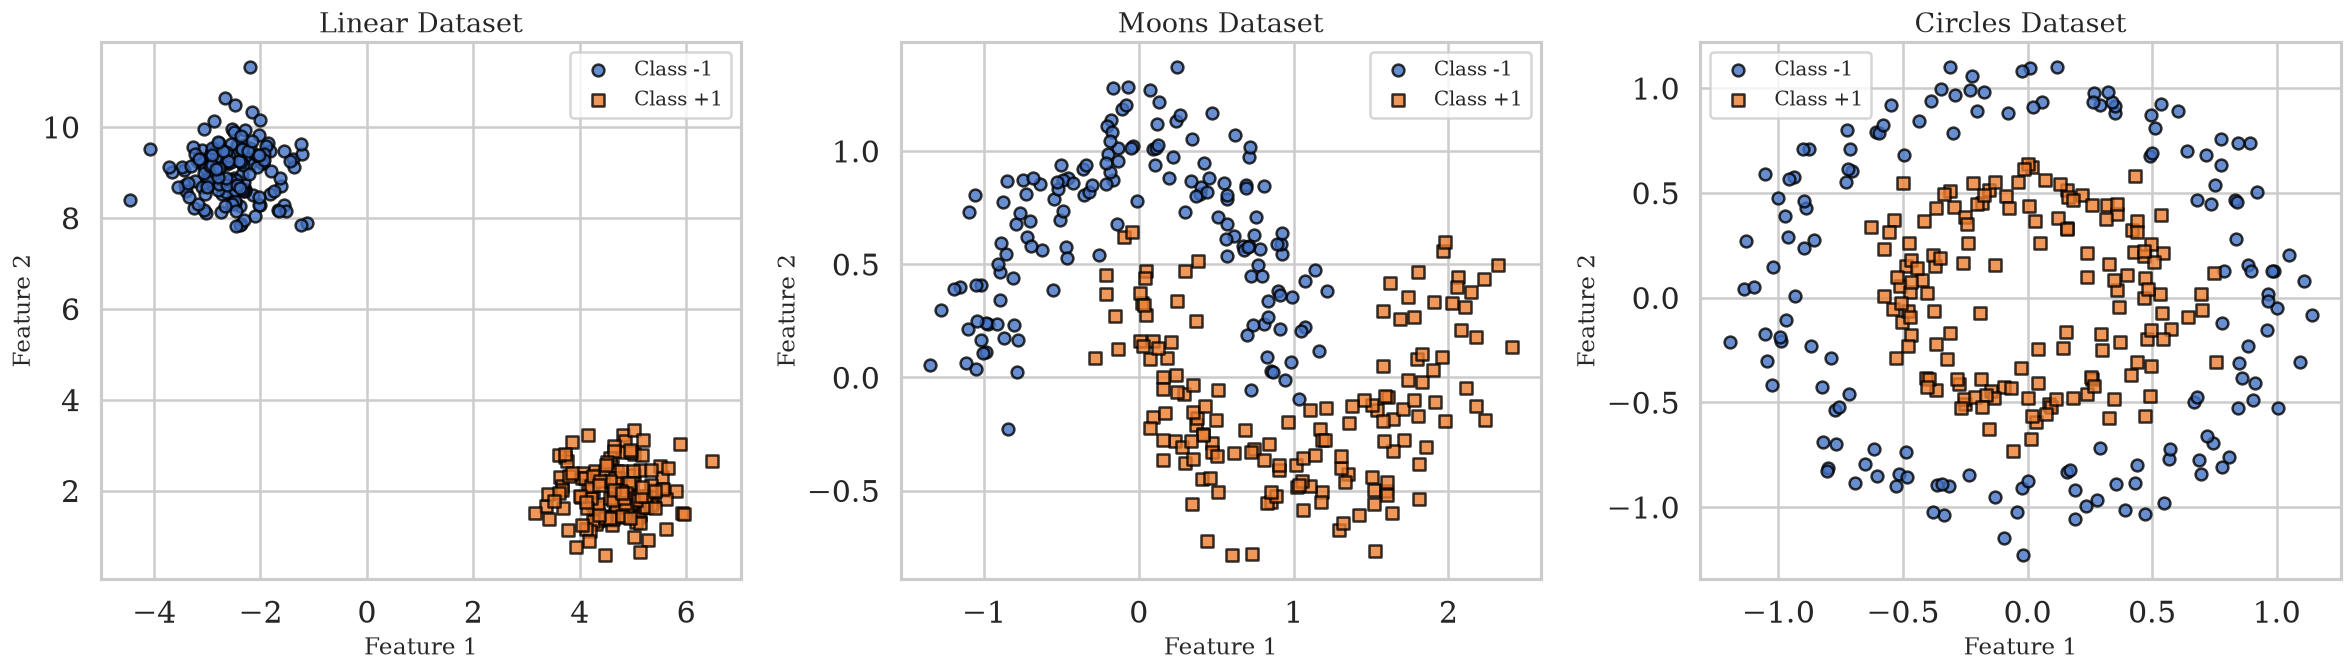

In [6]:
datasets = load_all_datasets(n_samples=300, random_state=42)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for ax, (name, (X, y)) in zip(axes, datasets.items()):
    plot_dataset(X, y, title=f"{name.title()} Dataset", ax=ax)
plt.tight_layout()
plt.show()

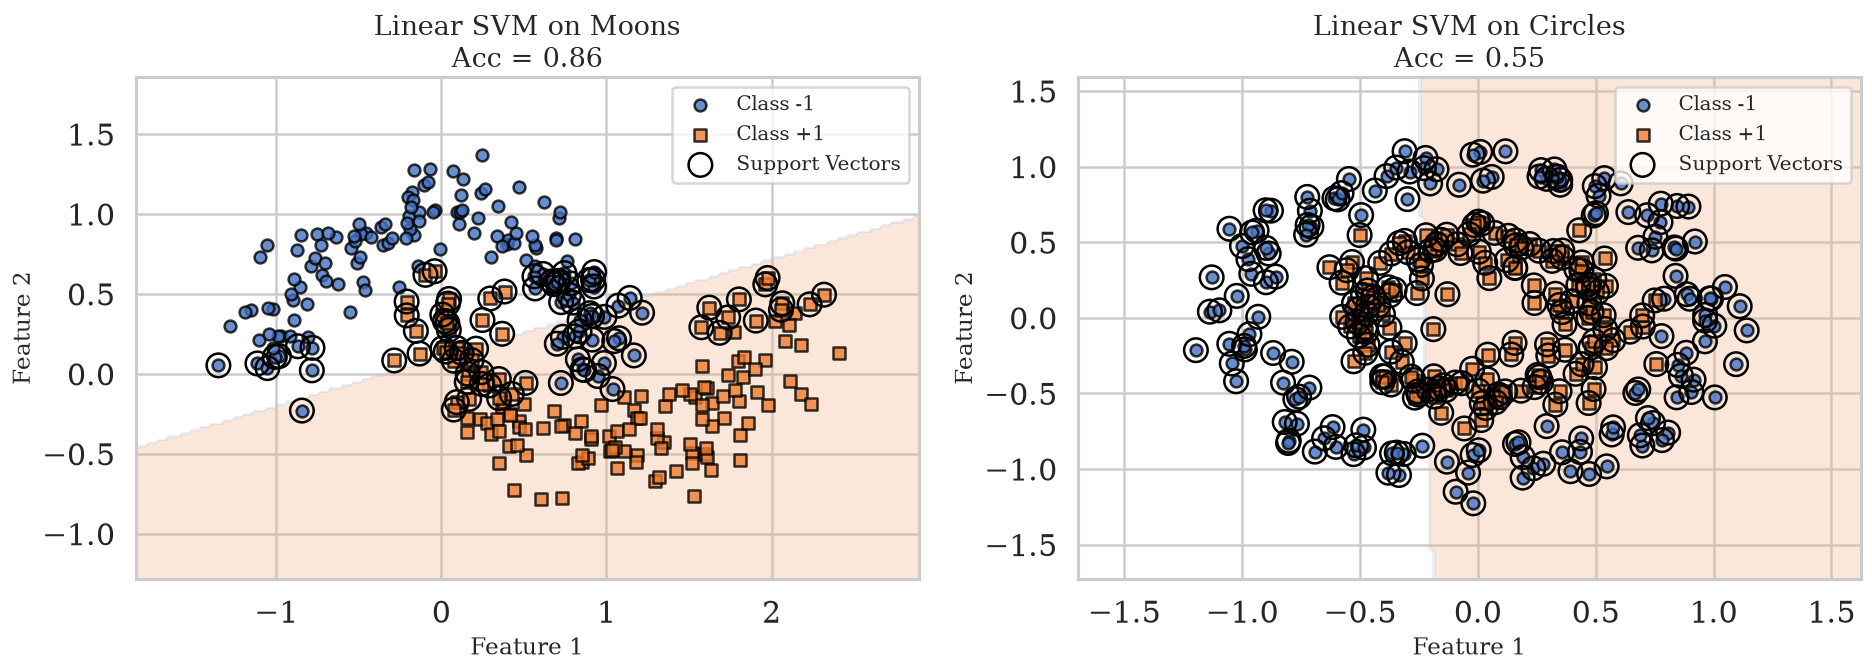

In [7]:
from rkhs_kernel_methods import make_nonlinear_datasets
nonlinear = make_nonlinear_datasets(n_samples=300, random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, (name, (X, y)) in zip(axes, nonlinear.items()):
    model = train_linear_svm(X, y, C=1.0, random_state=42)
    metrics = evaluate_model(model, X, y)
    plot_decision_boundary(
        model, X, y,
        title=f"Linear SVM on {name.title()}\nAcc = {metrics['accuracy']:.2f}",
        highlight_sv=True, ax=ax
    )
plt.tight_layout()
plt.show()

**Observation:** The linear SVM draws a straight line through the data. On circles, it misclassifies the entire inner class. On moons, it cuts through the crescents. The accuracy is poor because **no linear separator exists** in the original 2D space.

## Why does this happen?

A linear decision function has the form:

$$f(x) = w^\top x + b = \sum_{i} w_i x_i + b$$

This is a **hyperplane** in the input space. If the classes are not linearly separable (as with circles or moons), no choice of $w$ and $b$ can correctly classify the data.

## 2. The Kernel Trick: A Conceptual Introduction

The key idea:

1. **Map** data into a higher-dimensional **feature space** via $\Phi: \mathcal{X} \to \mathcal{H}$
2. **Separate** the data linearly in that high-dimensional space
3. **Avoid** explicitly computing $\Phi(x)$ by using a **kernel function**

The **kernel trick**:

$$k(x, y) = \langle \Phi(x), \Phi(y) \rangle_{\mathcal{H}}$$

We replace every dot product $\langle x_i, x_j \rangle$ in the SVM dual formulation with $k(x_i, x_j)$. This lets us learn a **nonlinear** boundary while only computing the kernel function in the original space!

## 3. Polynomial Kernel

The polynomial kernel is defined as:

$$k_{\text{poly}}(x, y) = (\gamma \cdot x^\top y + r)^d$$

- For $d=2$, this implicitly computes inner products in a feature space containing $x_1, x_2, x_1^2, x_2^2, x_1 x_2$ and cross terms.
- The parameter $d$ controls the complexity of the decision boundary.

Let's train a polynomial kernel SVM on the nonlinear datasets.

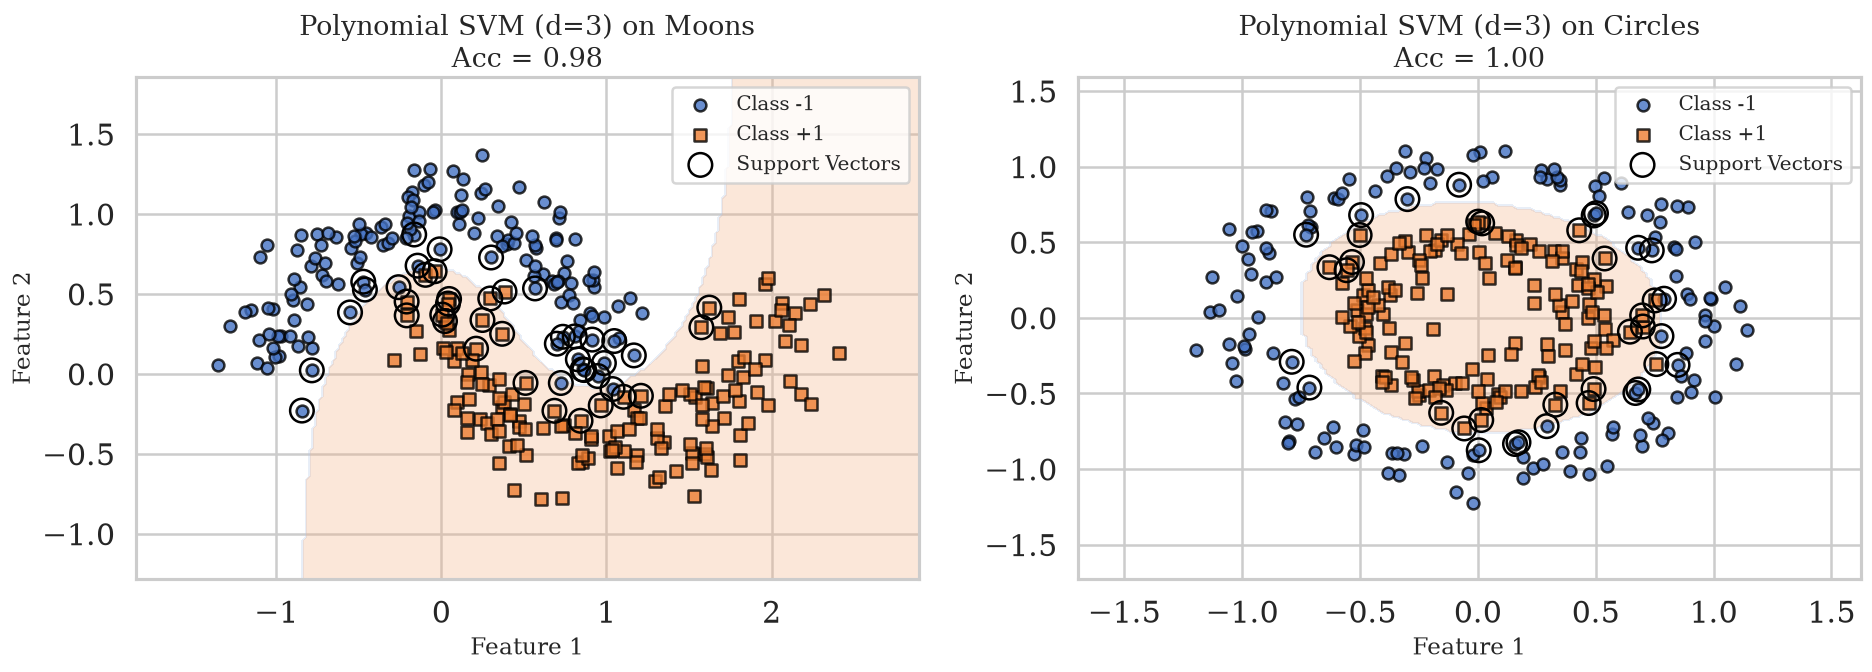

In [8]:
poly_results = {}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, (name, (X, y)) in zip(axes, nonlinear.items()):
    model = train_kernel_svm(X, y, kernel="poly", C=1.0, degree=3, gamma=1.0, random_state=42)
    metrics = evaluate_model(model, X, y)
    poly_results[name] = model
    plot_decision_boundary(
        model, X, y,
        title=f"Polynomial SVM (d=3) on {name.title()}\nAcc = {metrics['accuracy']:.2f}",
        highlight_sv=True, ax=ax
    )
plt.tight_layout()
plt.show()

**Observation:** The polynomial kernel with $d=3$ creates curved decision boundaries. It performs much better than the linear SVM, especially on the moons dataset. However, for circles it still struggles because the polynomial feature space is not perfectly suited for radial symmetry.

## 4. RBF (Gaussian) Kernel

The RBF kernel is defined as:

$$k_{\text{RBF}}(x, y) = \exp\left(-\gamma \, \|x - y\|^2\right)$$

- This kernel implicitly maps data into an **infinite-dimensional** feature space.
- The parameter $\gamma$ controls the influence radius: small $\gamma$ = wide influence, large $\gamma$ = narrow influence.
- It is the **most flexible** and widely-used kernel.

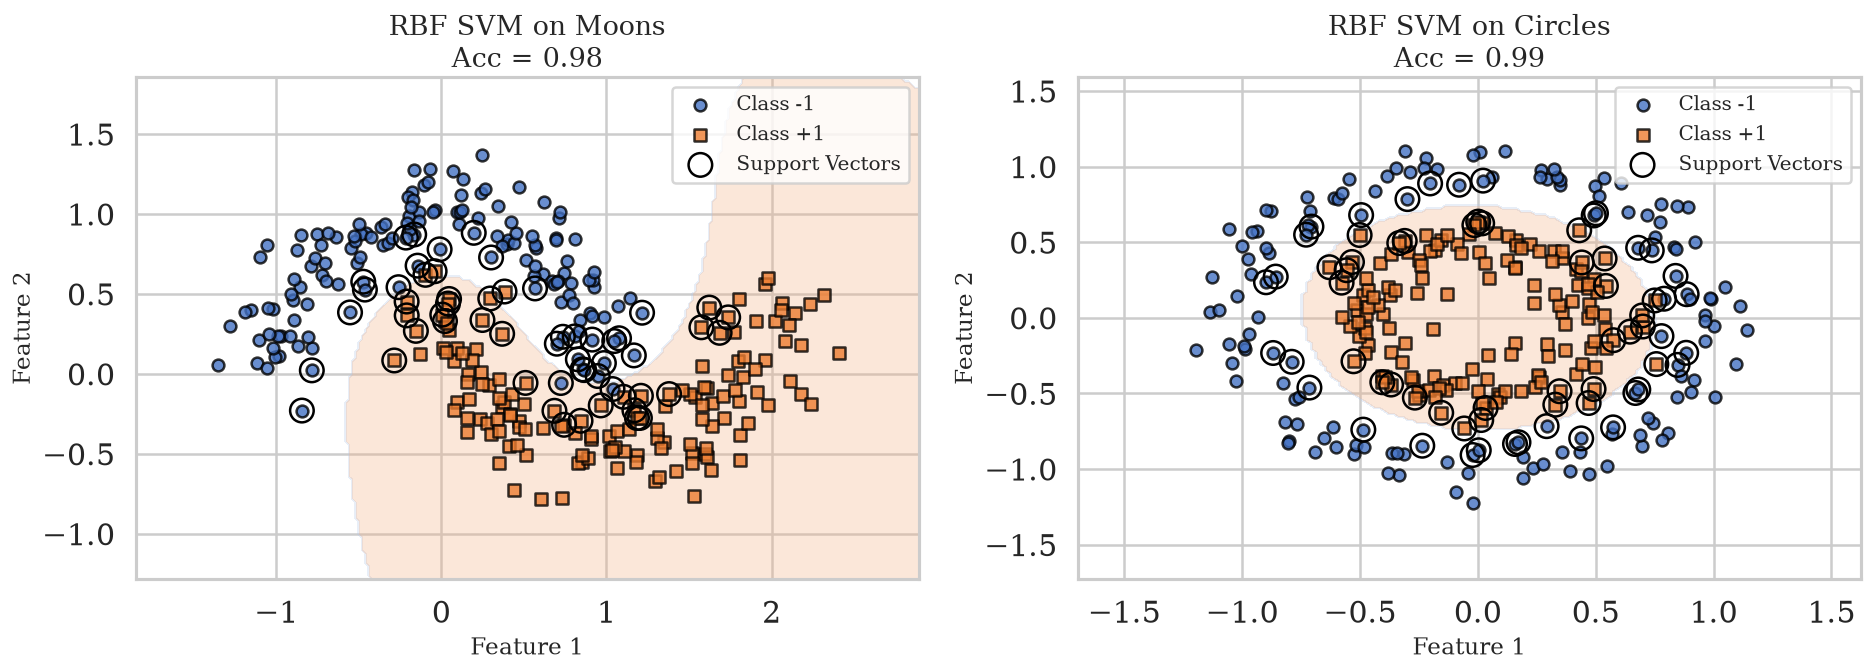

In [9]:
rbf_results = {}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, (name, (X, y)) in zip(axes, nonlinear.items()):
    model = train_kernel_svm(X, y, kernel="rbf", C=1.0, gamma=1.0, random_state=42)
    metrics = evaluate_model(model, X, y)
    rbf_results[name] = model
    plot_decision_boundary(
        model, X, y,
        title=f"RBF SVM on {name.title()}\nAcc = {metrics['accuracy']:.2f}",
        highlight_sv=True, ax=ax
    )
plt.tight_layout()
plt.show()

**Observation:** The RBF kernel achieves near-perfect classification on both datasets. On circles, it creates a circular boundary; on moons, it produces a smooth curve that follows the crescent shapes perfectly.

## 5. Side-by-Side Comparison: Linear vs Polynomial vs RBF

Let's visualize all three kernels on the circles dataset side by side.

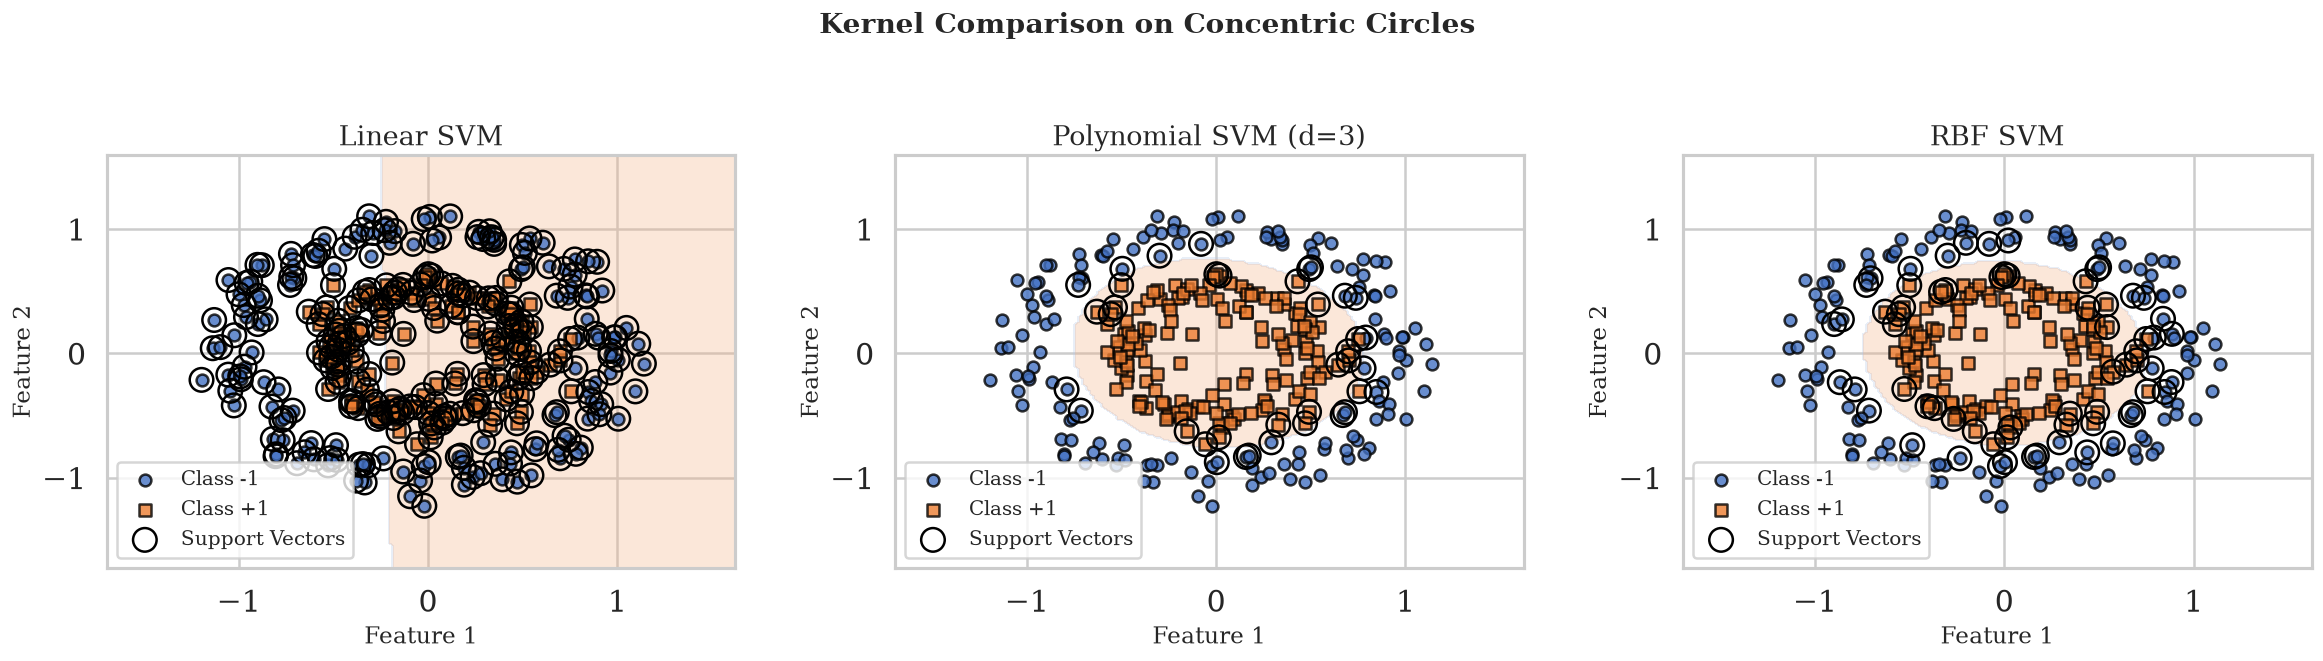

In [10]:
X_c, y_c = nonlinear["circles"]

models = {
    "Linear SVM": train_kernel_svm(X_c, y_c, kernel="linear", C=1.0, random_state=42),
    "Polynomial SVM (d=3)": train_kernel_svm(X_c, y_c, kernel="poly", C=1.0, degree=3, gamma=1.0, random_state=42),
    "RBF SVM": train_kernel_svm(X_c, y_c, kernel="rbf", C=1.0, gamma=1.0, random_state=42),
}

fig = plot_kernel_comparison(models, X_c, y_c, figsize=(20, 5.5))
fig.suptitle("Kernel Comparison on Concentric Circles", fontsize=17, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

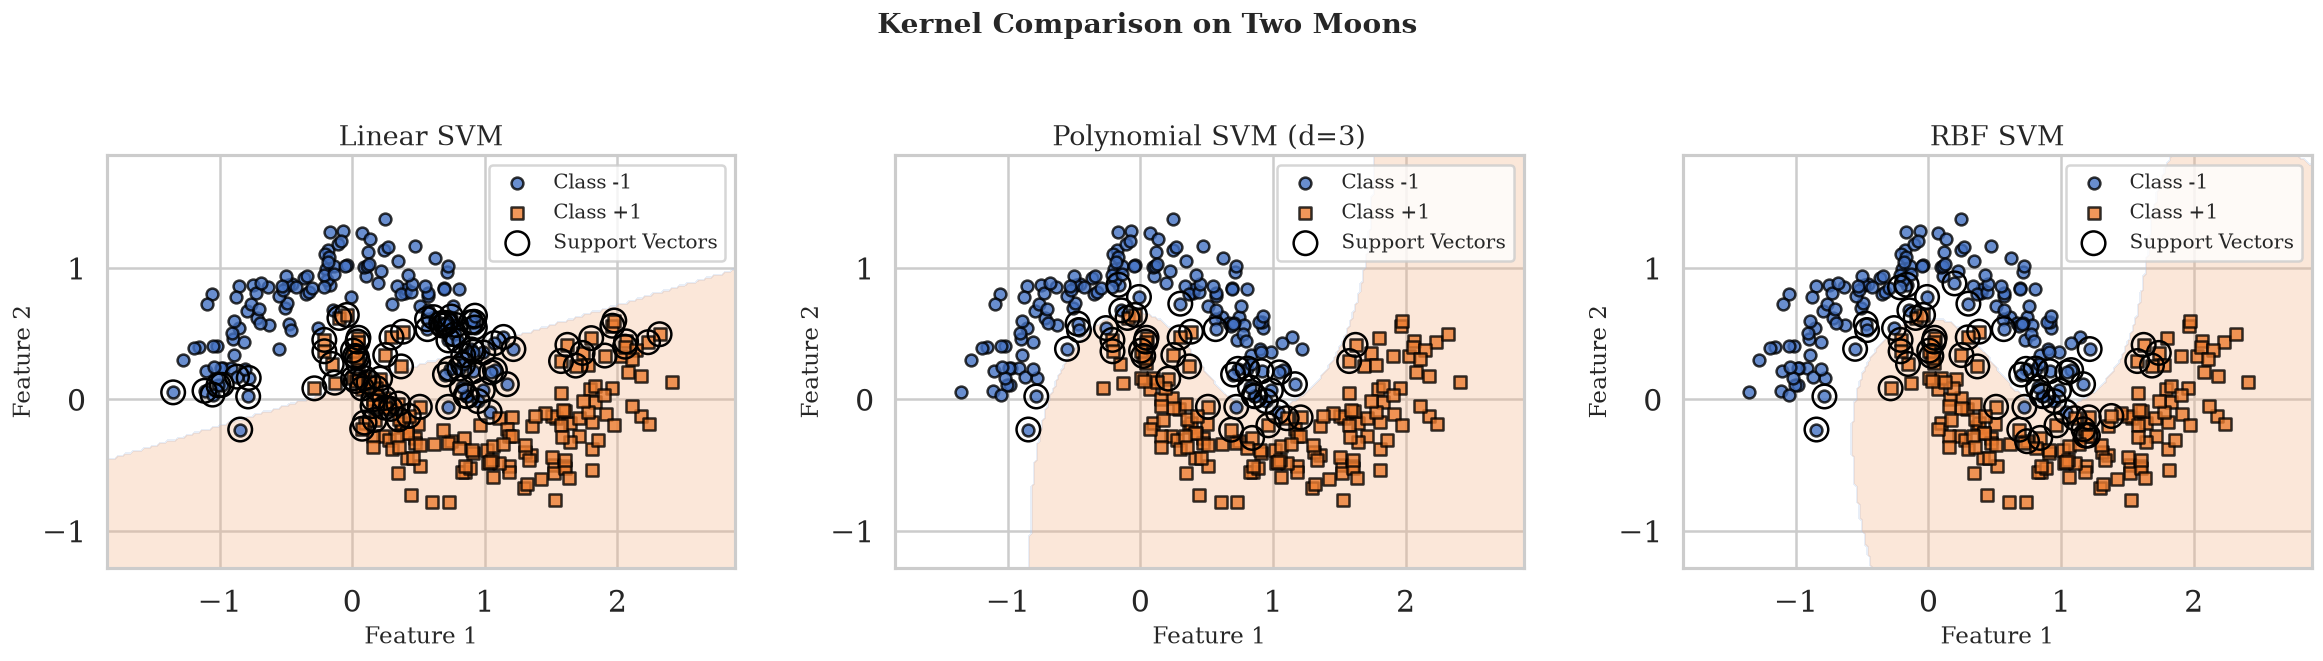

In [11]:
X_m, y_m = nonlinear["moons"]

models_m = {
    "Linear SVM": train_kernel_svm(X_m, y_m, kernel="linear", C=1.0, random_state=42),
    "Polynomial SVM (d=3)": train_kernel_svm(X_m, y_m, kernel="poly", C=1.0, degree=3, gamma=1.0, random_state=42),
    "RBF SVM": train_kernel_svm(X_m, y_m, kernel="rbf", C=1.0, gamma=1.0, random_state=42),
}

fig = plot_kernel_comparison(models_m, X_m, y_m, figsize=(20, 5.5))
fig.suptitle("Kernel Comparison on Two Moons", fontsize=17, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

In [12]:
print("=" * 70)
print("ACCURACY COMPARISON")
print("=" * 70)
for name, (X, y) in nonlinear.items():
    print(f"\n{name.upper()} Dataset:")
    for kernel_name in ["linear", "poly", "rbf"]:
        model = train_kernel_svm(X, y, kernel=kernel_name, C=1.0, random_state=42)
        acc = evaluate_model(model, X, y)["accuracy"]
        n_sv = len(model.support_vectors_)
        print(f"  {kernel_name:8s}  Accuracy: {acc:.3f}  |  Support Vectors: {n_sv}")

ACCURACY COMPARISON

MOONS Dataset:
  linear    Accuracy: 0.863  |  Support Vectors: 95
  poly      Accuracy: 0.983  |  Support Vectors: 45
  rbf       Accuracy: 0.983  |  Support Vectors: 57

CIRCLES Dataset:
  linear    Accuracy: 0.550  |  Support Vectors: 300
  poly      Accuracy: 0.997  |  Support Vectors: 38
  rbf       Accuracy: 0.993  |  Support Vectors: 65


## 6. The Magic: Implicit Feature Mapping

Consider the RBF kernel. Its feature space is **infinite-dimensional**. To see why, expand the exponential:

$$k_{\text{RBF}}(x, y) = e^{-\gamma \|x-y\|^2} = e^{-\gamma (\|x\|^2 + \|y\|^2 - 2x^\top y)} = \sum_{n=0}^{\infty} \frac{(2\gamma)^n}{n!} (x^\top y)^n e^{-\gamma(\|x\|^2 + \|y\|^2)}$$

This infinite Taylor series shows that the RBF kernel implicitly uses **all polynomial features of every degree**. The kernel trick lets us work with this infinite-dimensional space using only $\mathcal{O}(d)$ operations (just computing $\|x-y\|^2$).

### Why this matters:

1. **Computational efficiency**: We avoid the curse of dimensionality by never explicitly constructing $\Phi(x)$.
2. **Flexibility**: Any symmetric, positive definite function can serve as a kernel (Mercer's theorem).
3. **Modularity**: We can swap kernels without changing the SVM algorithm.
4. **Reproducing property**: The kernel defines an RKHS where evaluation is an inner product: $f(x) = \langle f, k(\cdot, x) \rangle$.

## Summary

- **Linear SVMs fail** on nonlinearly separable data like circles and moons because no hyperplane can separate them.
- The **kernel trick** $k(x, y) = \langle \Phi(x), \Phi(y) \rangle$ lets us compute inner products in a high-dimensional feature space without explicitly mapping the data.
- The **polynomial kernel** $(\gamma x^\top y + r)^d$ maps to a finite-dimensional polynomial feature space.
- The **RBF kernel** $\exp(-\gamma \|x-y\|^2)$ maps to an infinite-dimensional feature space and is the most flexible.
- Kernel SVMs achieve excellent performance on nonlinear problems while keeping the geometric intuition of maximum margin classification.